# Tarea 3: Clasificación de galaxias con una CNN

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

# Tarea 3

 Estudiantes:

 - Antonia Morales
 - Esteban Sánchez


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from keras.layers import Dropout

## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Cambio exitoso

In [ ]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [ ]:
path = "Binary_2_5_dataset.h5" #cambie este path al correspondiente suyo, en su carpeta drive

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(f"Tamaño de imagenes: {images.shape}")
print(f"Tamaño de labels: {labels.shape}")

Tamaño de imagenes: (4688, 256, 256, 3)
Tamaño de labels: (4688,)


# 1. Exploración de datos

## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [ ]:
X = images    # Asignamos las imagenes a la variable X
y = labels.astype("int32")    # Asignamos los labels a la variable Y

A continuación visualizamos imagenes aleatorias de ambas clases (0 & 1)

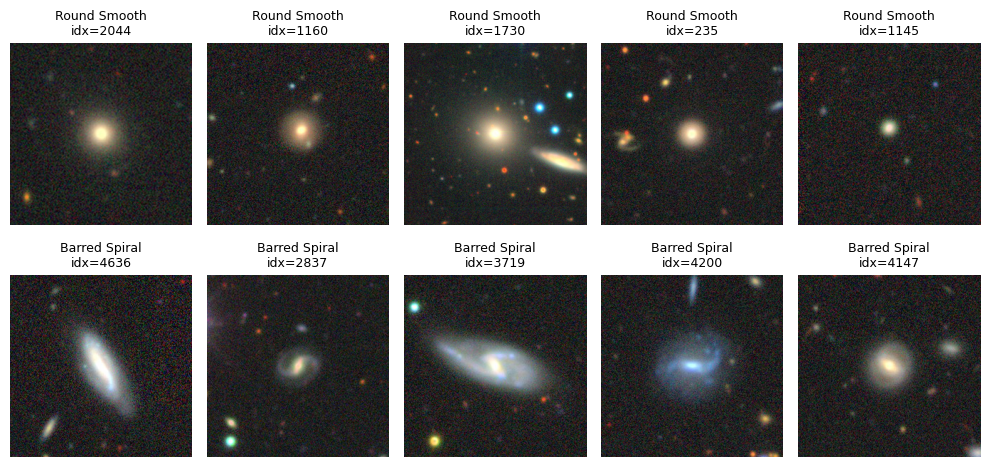

In [ ]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

* ¿Que diferencias visuales observa entre las galaxias smooth y las barred spiral?

Principalmente se puede observar que las **Round Smooth** muestran un núcleo brillante que decae suavemente desde el centro hacia afuera, sin estructuras internas marcadas, tales como brazos espirales ni patrones asimétricos. Cosa que si podemos apreciar en las imagenes de las galaxias **Barred Spiral**, donde se puede observar una barra central alargada y brazos espirales que se enrrollan hacia afuera de la galaxia, que se puede apreciar pese a las distintas escalas, donde a diferencia de las **Round Smooth**, éstas presentan una distribución de brillo mas irregular.

* ¿Qué características espera que pueda aprender la red?

Se espera que la red pueda aprender, por ejemplo, a diferenciar la presencia de brazos espirales o si existe un decaimiento suave del brillo central de la galaxia a lo largo del radio. También si hay una simetría a lo largo del núcleo o si se aprecian irregularidades en su morfología.

In [ ]:
classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(f"Clase {c}, Cantidad {n} ({(n*100/labels.shape[0]):.1f}%)")

razon = counts[1]/counts[0]
print(f"Razón de clases: {razon:.2f}")

Clase 0, Cantidad 2645 (56.4%)
Clase 1, Cantidad 2043 (43.6%)
Razón de clases: 0.77


In [ ]:
baseline_accuracy = counts.max() / counts.sum()
print(f"Accuracy de predecir de la clase más frecuente: {baseline_accuracy:.4f}")

Accuracy de predecir de la clase más frecuente: 0.5642


* ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?

El dataset muestra un leve desbalance de 56.4% de **Round Smooth** con un total de 2645, versus un 43.5% de **Barred Spiral** con un total de 2043, con una razón entre clases de 0.77, lo cual al ser un valor cercano a 1 nos indica que las clases están aceptablemente balanceadas, aunque con una leve inclinación por la clase **Round Smooth**. Para éste caso, a priori, el accuracy trivial para predecir la clase más frecuente lograría un valor 0.5642, lo cuál podría ser una metríca razonable, pero se requiere de otras (como precision, recall y F1-score) para no dejarnos engañar por la clase mayoritaria.

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [ ]:
# Separamos el test al 20%, estratificado por clase

X_temp, X_test, y_temp, y_test = train_test_split(X, y,
                                                  test_size=0.2, random_state=10, stratify=y)

# Luego, del resto separamos train/val en lo restante (80% y 20%)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,
                                                  test_size=0.2, random_state=10, stratify=y_temp)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

Train: (3000, 256, 256, 3) (3000,)
Val: (750, 256, 256, 3) (750,)
Test: (938, 256, 256, 3) (938,)
Train classes: (array([0, 1], dtype=int32), array([1693, 1307]))
Val classes: (array([0, 1], dtype=int32), array([423, 327]))
Test classes: (array([0, 1], dtype=int32), array([529, 409]))
Balance train: 0.43566666666666665 | val: 0.436 | test: 0.43603411513859275


* Justifique brevemente por qué es importante tener estos tres conjuntos

Es importante tener tres conjuntos separados ya que cada uno cumple un rol distinto; el de **entrenamiento** es que único conjunto que la red ve durante todo el proceso de ajuste, por lo que es el más grande para que la red tenga ejemplos suficientes a la hora de aprender patrones, el de **validación** se usa para comprobar el desempeño del entrenamiento en datos que no estén siendo usados por la red en el ajuste de los pesos y sirve para saber cuando detener el entrenamiento, mientras que el de **test** se utiliza al final del proceso para obtener la estimación no sesgada del desempeño del modelo en datos nuevos (y si se utilizara éste mismo conjunto para el ajuste el modelo quedaría sobreestimado, ya que indirectamente ajustaría los datos finales). Además, de ésta forma se mantiene el mismo balance de clase en los tres conjuntos (0.43566 o ~43.6%) utilizando stratify, para de ésta forma asegurarnos que la comparación sea justa y ningun conjunto esté "artificialmente" desproporcionado en clases.

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

- ¿Cuántas capas convolucionales usará? ¿Por qué cree que esa profundidad es suficiente para este problema?

Se usarán 3 capas convolucionales, a modo de balancear entre la complejidad de los datos y el costo computacional. Creemos que esto es suficiente, debido al tamaño de las imágenes (256x256).

- ¿Cuántos filtros tendrá cada capa convolucional? ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

En capas más profundas, los patrones que capturan los filtros se vuelven cada vez más complejos, lo que propicia la necesidad de aumentar la cantidad de filtros a medida que se progresa en la red. En este caso, se usarán 8 y 16 filtros en las respectivas capas convolucionales

- ¿Qué función de activación usará en las capas internas? ¿Por qué?

Se utilizará ReLU como función de activación pues es una manera matemáticamente simple de introducir no-linealidad a la red y rápida en tiempos computacionales.

- ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación? ¿Qué ventaja tiene esto?

Se usará `MaxPooling2D`, en primer lugar, para reducir costos computacionales, pero también para rescatar las variaciones más importantes en las imágenes, de manera que la red no se vea afectada por pequeños cambios dentro de éstas.

- ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa? ¿Qué diferencia hay entre ambas opciones?

Mientras que `Flatten` transforma los feature maps en vectores unidimensionales, `GlobalAveragePooling2D` entrega un tensor 2D. En este caso, se utilizará `GlobalAveragePooling2D`, debido a que `Flatten` puede resultar en capas densas muy grandes, llevando a un alto costo computacional y riesgo de overfitting.

- ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`? ¿Por qué podría ser necesaria en este dataset?

Para reducir overfitting, se incluirá `EarlyStopping`. El problema que se presenta en este trabajo es de alta complejidad, y es posible que, pasado el tiempo, el modelo tienda a sobrecomplejizarse.

- ¿Qué función de activación debe tener la capa de salida? ¿Por qué esa elección es adecuada para una clasificación binaria?

Para la capa de salida se utilizará una función sigmoide. Esta es recomendada en problemas de clasificación binaria, pues produce outputs que van entre 0 y 1.

- ¿Qué función de pérdida usará? Justifique su elección considerando que el problema tiene dos clases.

Como el problema tiene dos clases, es del tipo clasificación binaria. En este contexto, Binary Cross Entropy es útil, ya que calcula la probabilidad de que el input pertenezca a cada una de las dos categorías.


## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(2, kernel_size=5x5, activation='ReLU')
```layers

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.GlobalAveragePooling2D()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(16, activation='ReLU')
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(1, activation='sigmoid')
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

## 4. Entrenamiento

In [ ]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), #capa de entrada, cantidad de neuronas igual a la cantidad de features
    layers.Rescaling(1./255), #capa de normalización
    layers.Dropout(0.2),

    # Bloque convolucional 1
    layers.Conv2D(8, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(),

    # Bloque convolucional
    layers.Conv2D(16, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(),

    # Segundo bloque convolucional
    layers.Conv2D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(),

    # Parte final de clasificación, capa de pooling
    layers.GlobalAveragePooling2D(),

    layers.Dense(32, activation='relu'), #capa densa fully connected

    # Capa de salida
    layers.Dense(1, activation= 'sigmoid')
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary() #resumen de la arquitectura de la red

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 252, 252, 8)    │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 126, 126, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 122, 122, 16)   │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 61, 61, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 57, 57, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,033 (273.57 KB)

 Trainable params: 70,033 (273.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, # puede modificar este valor
    batch_size=16,# puede modificar este valor
    callbacks=[early_stop]
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.9170 - loss: 0.2044 - val_accuracy: 0.8920 - val_loss: 0.2523
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9263 - loss: 0.1770 - val_accuracy: 0.9373 - val_loss: 0.1733
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9253 - loss: 0.1705 - val_accuracy: 0.9133 - val_loss: 0.2392
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9260 - loss: 0.1765 - val_accuracy: 0.9400 - val_loss: 0.1635
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9340 - loss: 0.1585 - val_accuracy: 0.9360 - val_loss: 0.1772
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9433 - loss: 0.1384 - val_accuracy: 0.9307 - val_loss: 0.1653
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9383 - loss: 0.1490 - val_accuracy: 0.9440 - val_loss: 0.1540
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9437 - loss: 0.1369 - val_acc

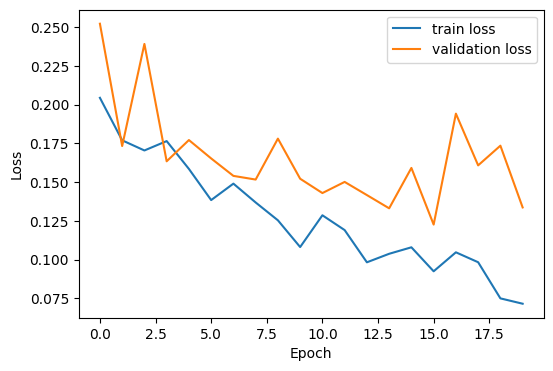

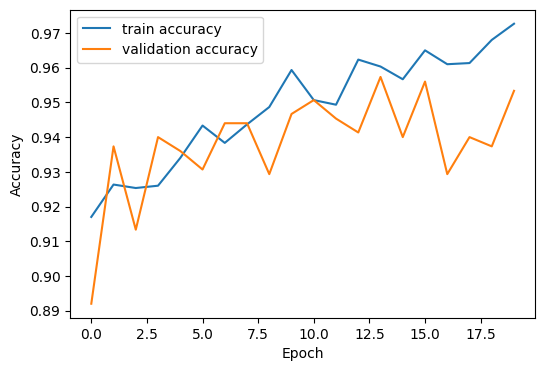

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Mientras que en el set de train la accuracy sube constantemente y la loss muestra una tendencia a la baja, esto es algo diferente para los datos de validación; hay cierta inestabilidad tanto en accuracy como en loss. Aún así, se aprecia que a largo plazo hay una mejora en ambos valores. Al observar los gráficos es posible advertir que el accuracy de entrenamiento es más alto que el de validación y, del mismo modo, la pérdida es más baja en entrenamiento, lo que representa una señal de ligero overitting. Sin embargo, consideramos que es un resultado razonable, pues la brecha entrenamiento-validación no es significativa.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9478 - loss: 0.1286
Test loss: 0.1286
Test accuracy: 0.9478


## 5. Evaluación del modelo

#### Genere la matriz de confusión y las métricas

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
[[510  19]
 [ 30 379]]


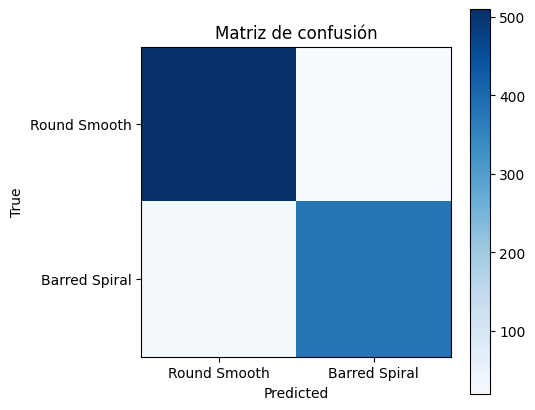

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.colorbar()
plt.xticks([0, 1], ["Round Smooth", "Barred Spiral"])
plt.yticks([0, 1], ["Round Smooth", "Barred Spiral"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
# Generación de las métricas

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Precision: 0.9523
Recall: 0.9267
F1-score: 0.9393


* ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique

El accuracy obtenido de 0.95 (o 95%) supera con creces el baseline de predecir siempre la clase prioritaria (56.4%), lo que confirma que el modelo está aprendiendo y no se está aprovechando del desbalance de clases.
De todas las métricas obtenidas, la más baja es recall, dando a entender que el modelo es más preciso (acierta en sus predicciones) que completo (encuentra las galaxias **Round Smooth**). Sin embargo, el margen entre estas métricas es pequeño, y ambos números superan el 90%, por lo que el modelo puede ser considerado como un buen clasificador de galaxias.

En caso de querer mejorarse el modelo, es necesario tener una imagen más completa de donde falla, tarea para la que sólo observar accuracy no es suficiente, y podría inducir a sesgo.



## 6. Análisis de errores

#### Revise algunos ejemplos de galaxias mal clasificadas

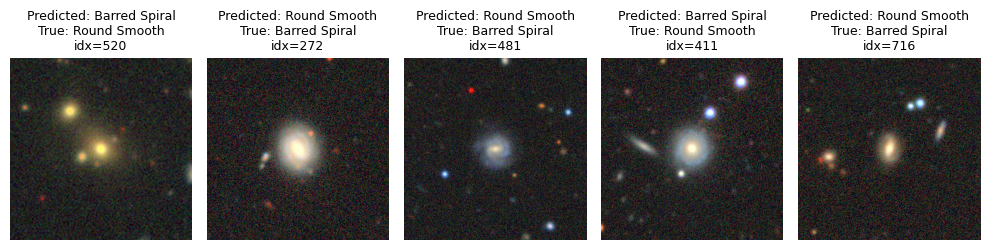

In [ ]:
bad_idxs = np.where(y_pred.flatten() != y_test)[0]
bad_idxs = rng.choice(bad_idxs, size=5, replace=False)

plt.figure(figsize=(10, 5))

for j, idx in enumerate(bad_idxs):
    plt.subplot(1, 5, j + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Predicted: {class_names[y_pred[idx][0]]}\nTrue: {class_names[y_test[idx]]}\nidx={idx}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

* ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
* Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

Observando las imágenes, no se ve a priori que parezcan errores claros del modelo, sino más bien casos morfológicamente ambiguos. Para las **Round Smooth** mal clasificadas, se puede ver un halo no tan simétrico, posiblemente atribuible a la baja resolución de la imagen, y sumandole la contaminación de objetos cercanos, el modelo los puede interpretar como estructura espiral correspondiente a la galaxia. Mientras que para las **Barred Spiral** mal clasificadas, considerando el bajo brillo y el pequeño tamaño angular que se puede observar, hacen que la barra central o los brazos espirales se hagan poco diferenciables, quedando visualmente más cercano a una Round Smooth inclusive a la inspección visual humana.

#### Conclusiones y comentarios finales

* A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

Considerando los resultados, se puede decir que el modelo sí aprende diferencias morfológicas reales entre galaxias **Round Smooth** y **Barred Spiral**, logrando abordar el problema inicialmente presentado. La evidencia más sólida de ésto, es que además de presentar valores aceptables en las métricas, los errores visualizados en el punto 6 indican que los casos donde el modelo no puede clasificar bien son morfológicamente ambiguos (ya sea por contaminación cercana, resolución de la imagen, etc.).

Lo logrado durante este trabajo es producto del proceso de ajuste del modelo, ya que debieron probarse diversas alternativas y parámetros para llegar a un buen resultado. Por ejemplo, se tenía la hipótesis de que agregar `Dropout` robustecería el modelo, pero esto sólo indujo severa inestabilidad en la evolución de las métricas tanto de training como de validación, resultando en un mayor loss y un menor accuracy y, por ende, un modelo con menor capacidad para predecir clases. El proceso de probar con diferentes parámetros y configuraciones fue clave para lograr una mejoría y realizar un mejor trabajo de clasificación de los datos.

A partir del trabajo realizado y los resultados obtenidos, puede concluirse que aprendimos a entrenar redes neuronales convolucionales y entender sus parámetros y cómo estos afectan la eficacia de un modelo para resolver un problema determinado.